# Model

In [33]:
# Setup imports and paths
import os
import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

# Make sure repository root is on sys.path (adjust if you open the notebook from a different folder)
REPO_ROOT = Path('..').resolve() if Path('.').name == 'notebooks' else Path('.').resolve()
print(f'REPO_ROOT = {REPO_ROOT}')
sys.path.insert(0, str(REPO_ROOT))

# Helpful device selection
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

REPO_ROOT = D:\thesis work\densnet-thesis\notebooks
Using device: cpu


In [34]:
from pathlib import Path  # <-- add this at the top
import os
from datetime import datetime

# User-editable settings
# Allow override from environment variable MODEL_PATH (convenient for CI / shells)
MODEL_PATH = os.environ.get('MODEL_PATH', None)
DATA_ROOT = None
NUM_BENCH_SAMPLES = 10
NUM_EXPLAIN_SAMPLES = 3

# If you know the folder containing your checkpoint, set it here (the notebook will pick the newest file inside).
# Example (you provided this path):
DEFAULT_MODEL_DIR = Path(r'D:\thesis work\densnet-thesis\weight\save\40')

# Auto-discover model if MODEL_PATH is None
if MODEL_PATH is None:
    # Common places to look for checkpoints (DEFAULT_MODEL_DIR is included first)
    search_roots = [DEFAULT_MODEL_DIR, Path('weight'), Path('weight/save'), Path('models'), Path('model'), Path('checkpoints'), Path('.')]
    patterns = ['*.pth', '*.pt', '*.pth.tar', '*.tar']
    candidates = []
    for root in search_roots:
        try:
            if root.exists():
                for pat in patterns:
                    candidates.extend(list(root.rglob(pat)))
        except Exception:
            # ignore permissions/IO errors for some roots
            continue

    # deduplicate and sort by modification time (newest first)
    unique = {str(p): p for p in candidates}
    candidates = list(unique.values())
    candidates = sorted(candidates, key=lambda p: p.stat().st_mtime if p.exists() else 0, reverse=True)
    candidates = [str(p) for p in candidates]
    if candidates:
        print('Found candidate checkpoints (sorted by modification time, newest first):')
        for c in candidates[:10]:
            try:
                mtime = datetime.fromtimestamp(Path(c).stat().st_mtime).isoformat()
            except Exception:
                mtime = 'unknown'
            print(' -', c, '(mtime:', mtime + ')')
        MODEL_PATH = candidates[0]
    else:
        print('No checkpoint auto-discovered. Please set MODEL_PATH to your checkpoint file path or set the MODEL_PATH environment variable.')
else:
    # If user set MODEL_PATH to a directory, pick the newest checkpoint inside it
    mp = Path(MODEL_PATH)
    if mp.exists() and mp.is_dir():
        patterns = ['*.pth', '*.pt', '*.pth.tar', '*.tar']
        cand = []
        for pat in patterns:
            cand.extend(list(mp.rglob(pat)))
        cand = sorted({str(p): p for p in cand}.values(), key=lambda p: p.stat().st_mtime if p.exists() else 0, reverse=True)
        if cand:
            MODEL_PATH = str(cand[0])
            print(f'MODEL_PATH was a directory; selecting newest checkpoint inside: {MODEL_PATH}')
        else:
            print(f'MODEL_PATH points to a directory but no checkpoints were found inside: {MODEL_PATH}')
    else:
        print('MODEL_PATH provided via environment variable or earlier assignment.')

print('MODEL_PATH =', MODEL_PATH)


Found candidate checkpoints (sorted by modification time, newest first):
 - D:\thesis work\densnet-thesis\weight\save\40\iaff40_5.pth (mtime: 2025-10-13T03:03:24.372919)
MODEL_PATH = D:\thesis work\densnet-thesis\weight\save\40\iaff40_5.pth


In [35]:
# Robust model loader: handles checkpoints that store 'model' or 'model_state_dict'
import torch
import sys
from importlib import import_module
import numpy as np
# Ensure repository root is on sys.path so local modules (config, model.*) can be imported
sys.path.insert(0, r'D:\thesis work\densnet-thesis')
import config

def load_checkpoint_model(checkpoint_path, device=DEVICE):
    # Use safe_globals to allowlist numpy types needed by this checkpoint (trusted local file)
    with torch.serialization.safe_globals([np._core.multiarray.scalar, np.dtype]):
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = None
    # If the checkpoint saved the whole model object (common in this repo)
    if isinstance(checkpoint, dict) and 'model' in checkpoint:
        model = checkpoint['model']
        model.to(device)
        model.eval()
        print('Loaded model object from checkpoint.')
        return model, device

    # If a state_dict is present, attempt to instantiate a model and load the weights
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        print('Checkpoint contains state_dict. Attempting to instantiate model and load weights...')
        # Try common model factories found in repository
        try:
            # Try multiclass factory first
            from model.multiclass_model import create_multiclass_model
            model = create_multiclass_model(num_classes=getattr(config, 'class_num', 2))
            model.load_state_dict(checkpoint['model_state_dict'])
            model.to(device)
            model.eval()
            print('Instantiated MultiClass model and loaded state_dict.')
            return model, device
        except Exception as e_mult:
            print('Multiclass factory failed:', e_mult)
        try:
            from model.model import class_model
            model = class_model()
            model.load_state_dict(checkpoint['model_state_dict'])
            model.to(device)
            model.eval()
            print('Instantiated binary/class_model and loaded state_dict.')
            return model, device
        except Exception as e_bin:
            print('Binary factory failed:', e_bin)

    # If checkpoint is just a model object (not dict) try that
    if not isinstance(checkpoint, dict):
        try:
            model = checkpoint
            model.to(device)
            model.eval()
            print('Checkpoint appears to be a model object (direct load).')
            return model, device
        except Exception as e_obj:
            print('Could not use checkpoint as model object:', e_obj)

    raise RuntimeError('Failed to load model from checkpoint. Please inspect the checkpoint file or update the loader cell.')

# Try to load if MODEL_PATH was discovered
model = None
if MODEL_PATH:
    model, DEVICE = load_checkpoint_model(MODEL_PATH, DEVICE)
else:
    print('No MODEL_PATH set. Set MODEL_PATH and re-run this cell to load the model.')


Loaded model object from checkpoint.


In [36]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from pathlib import Path

IMG_SIZE = 224
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)
BATCH_SIZE = 32
NUM_WORKERS = 0

# Root folder containing subfolders for each class (benign, malignant, etc.)
data_root = r"D:\thesis work\densnet-thesis\datasets\BreaKHis 400X\test"
print('Using data root for test set:', data_root)

# Check path exists
if not Path(data_root).exists():
    raise FileNotFoundError(f"Dataset path does not exist: {data_root}")

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# ImageFolder expects: test/class_name/*.png
test_dataset = ImageFolder(data_root, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Test dataset size: {len(test_dataset)} samples, batches: {len(test_loader)}')
class_names = test_dataset.classes
print('Class names:', class_names)


Using data root for test set: D:\thesis work\densnet-thesis\datasets\BreaKHis 400X\test
Test dataset size: 545 samples, batches: 18
Class names: ['benign', 'malignant']


In [37]:
# Run evaluation (accuracy, precision, recall, f1, confusion matrix, ROC-AUC for binary)
from evaluation.metrics import ModelEvaluator
import numpy as np
import json

evaluator = ModelEvaluator(class_names=class_names)
results = evaluator.evaluate_model(
    model, test_loader, device=DEVICE,
    save_results=True, save_dir='notebook_evaluation_results'
)

# Print a compact summary
metrics = results['metrics']
print('Overall metrics:')
for k in ['accuracy', 'precision', 'recall', 'f1_score']:
    print(f' - {k}:', metrics.get(k))

if 'confusion_matrix' in metrics:
    print('\nConfusion matrix:')
    print(np.array(metrics['confusion_matrix']))

# Save summary JSON for convenience
with open('notebook_evaluation_results/summary.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Saved evaluation summary to notebook_evaluation_results/summary.json')


Starting comprehensive model evaluation...


KeyboardInterrupt: 

# Explaibility

## IUC, means etc

In [ ]:
# Run quantitative explainability benchmarking (IoU, insertion/deletion AUC, stability)
from explainability.quantitative_benchmarking import QuantitativeExplainabilityBenchmark

benchmark = QuantitativeExplainabilityBenchmark(model, device=str(DEVICE), class_names=class_names)
# Use a small number of samples to test; increase NUM_BENCH_SAMPLES for thorough runs
bench_results = benchmark.run_comprehensive_benchmark(test_loader, num_samples=NUM_BENCH_SAMPLES, methods=None, ground_truth_masks=None, save_dir='notebook_explainability_benchmark')

print('Benchmark summary (per method):')
for method, data in bench_results.items():
    print(method, '-> insertion_auc mean:', data.get('insertion_auc', {}).get('mean'), 'iou mean:', data.get('iou', {}).get('mean'))

Starting quantitative explainability benchmark...
Methods: ['gradcam', 'gradcam_plus']
Samples: 10
Evaluating sample 1/10
Evaluating sample 1/10
Error generating gradcam explanation: element 0 of tensors does not require grad and does not have a grad_fn
Error generating gradcam explanation: element 0 of tensors does not require grad and does not have a grad_fn
Error generating gradcam_plus explanation: element 0 of tensors does not require grad and does not have a grad_fn
Evaluating sample 2/10
Error generating gradcam_plus explanation: element 0 of tensors does not require grad and does not have a grad_fn
Evaluating sample 2/10
Error generating gradcam explanation: element 0 of tensors does not require grad and does not have a grad_fn
Error generating gradcam explanation: element 0 of tensors does not require grad and does not have a grad_fn
Error generating gradcam_plus explanation: element 0 of tensors does not require grad and does not have a grad_fn
Evaluating sample 3/10
Error ge

In [ ]:
# Generate explanations for a few sample images and visualize (Grad-CAM, Grad-CAM++, SHAP, LIME where available)
import torch.nn.functional as F
from explainability.grad_cam import GradCAM, GradCAMPlusPlus, overlay_heatmap
from explainability.shap_explainer import SHAPExplainer
from explainability.lime_explainer import LIMEExplainer

# Helper: convert tensor -> displayable image (denormalize)
def tensor_to_image(tensor, mean=MEAN, std=STD):
    denorm = tensor.clone()
    for c in range(3):
        denorm[0, c] = denorm[0, c] * std[c] + mean[c]
    img = denorm[0].cpu().numpy().transpose(1,2,0)
    img = np.clip(img, 0, 1)
    return img

# Sample few images from test_loader
samples = []
for images, labels in test_loader:
    for i in range(min(images.size(0), NUM_EXPLAIN_SAMPLES - len(samples))):
        samples.append((images[i:i+1].to(DEVICE), int(labels[i].item())))
    if len(samples) >= NUM_EXPLAIN_SAMPLES:
        break

# Initialize simple explainers for single-sample visualization
# Choose a target layer name heuristically
layer_name_candidates = ['densenet.features.norm5','features.norm5','norm5']
# pick first available target layer from model modules
layer_names = [name for name, _ in model.named_modules()]
target_layer = next((ln for ln in layer_name_candidates if ln in layer_names), None)
if target_layer is None:
    convs = [n for n in layer_names if 'conv' in n.lower()]
    target_layer = convs[-1] if convs else None
print('Using Grad-CAM target layer:', target_layer)

try:
    gradcam = GradCAM(model, target_layer_name=target_layer) if target_layer else None
    gradcam_plus = GradCAMPlusPlus(model, target_layer_name=target_layer) if target_layer else None
    print('Grad-CAM instances ready')
except Exception as e:
    print('Grad-CAM init failed:', e)
    gradcam = gradcam_plus = None

# Optionally initialize SHAP and LIME (may be slow)
shap_explainer = None
lime_explainer = None
try:
    shap_explainer = SHAPExplainer(model, torch.randn(3,3,IMG_SIZE,IMG_SIZE).to(DEVICE), str(DEVICE))
    print('SHAP explainer ready')
except Exception as e:
    print('SHAP init failed:', e)

try:
    lime_explainer = LIMEExplainer(model, str(DEVICE), num_samples=50)
    print('LIME explainer ready')
except Exception as e:
    print('LIME init failed:', e)

# Iterate and visualize
for idx, (img_t, true_label) in enumerate(samples):
    print(f'--- Sample {idx+1} (true label: {true_label})')
    with torch.no_grad():
        out = model(img_t.to(DEVICE))
        probs = F.softmax(out, dim=1)
        pred = int(torch.argmax(probs, dim=1).item())
        conf = float(probs[0, pred].item())
    display_img = tensor_to_image(img_t, mean=MEAN, std=STD)

    explanations = {}
    if gradcam is not None:
        try:
            explanations['gradcam'] = gradcam.generate_cam(img_t, pred)
        except Exception as e:
            print('Grad-CAM failed for sample:', e)
    if gradcam_plus is not None:
        try:
            explanations['gradcam_plus'] = gradcam_plus.generate_cam(img_t, pred)
        except Exception as e:
            print('Grad-CAM++ failed for sample:', e)
    if shap_explainer is not None:
        try:
            shap_vals = shap_explainer.explain_image(img_t, pred)
            if shap_vals is not None:
                heat = np.sum(np.abs(shap_vals), axis=0)
                heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
                explanations['shap'] = heat
        except Exception as e:
            print('SHAP failed for sample:', e)
    if lime_explainer is not None:
        try:
            image_np = img_t[0].cpu().numpy().transpose(1,2,0)
            image_np = np.clip(image_np * STD + MEAN, 0, 1)
            lime_exp, segs = lime_explainer.explain_image(image_np)
            temp, mask = lime_exp.get_image_and_mask(pred, positive_only=False, num_features=10, hide_rest=False)
            maskf = (mask.astype(float) - mask.min()) / (mask.max() - mask.min() + 1e-8)
            explanations['lime'] = maskf
        except Exception as e:
            print('LIME failed for sample:', e)

    # Visualization: original + heatmaps + overlays
    num = 1 + len(explanations)
    cols = min(4, num)
    rows = (num + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.array(axes).reshape(-1)
    axes[0].imshow(display_img)
    axes[0].set_title(f'Original (pred={pred}, conf={conf:.2f})')
    axes[0].axis('off')
    i = 1
    for name, heat in explanations.items():
        if i >= len(axes):
            break
        im = axes[i].imshow(heat, cmap='jet')
        axes[i].set_title(name.upper())
        axes[i].axis('off')
        plt.colorbar(im, ax=axes[i], fraction=0.04)
        i += 1
    plt.tight_layout()
        plt.show()

    # Overlay visualizations
    if explanations:
        fig2, ax2 = plt.subplots(1, len(explanations), figsize=(5*len(explanations), 5))
        if len(explanations) == 1:
            ax2 = [ax2]
        j = 0
        for name, heat in explanations.items():
            overlay = overlay_heatmap(display_img, heat, alpha=0.4)
            ax2[j].imshow(overlay)
            ax2[j].set_title(name + ' overlay')
            ax2[j].axis('off')
            j += 1
        plt.tight_layout()
        plt.show()

# --- Extended explainability analyses: Integrated Gradients (multi-baseline), Occlusion, validations ---

# This cell adds functions and a small runner to compute the requested methods:",

        baselines = [torch.zeros_like(input_tensor)]
    if CAPTUM_AVAILABLE:
        # average attributions over baselines (multi-baseline IG)
        for b in baselines:
            attr = ig.attribute(input_tensor.to(device), baselines=b, target=target, n_steps=steps)
        return (attributions_sum / len(baselines)).detach().cpu().numpy()[0]

In [ ]:
# Continued: reinitialization / validation helpers and runner
import copy
from pathlib import Path

# Reinitialize model parameters (best-effort)
def reinitialize_model_weights(m):
    for name, p in m.named_parameters():
        if p.requires_grad:
            try:
                torch.nn.init.normal_(p)
            except Exception:
                try:
                    p.data.zero_()
                except Exception:
                    pass

# Zero out last n parameter tensors (best-effort downgrade)
def zero_out_last_parameters(m, n_params=1):
    params = list(m.named_parameters())
    if not params:
        return
    for name, p in params[-n_params:]:
        with torch.no_grad():
            p.data.zero_()

# Model randomization sanity check runner
def run_model_randomization_check(model, input_tensor, target, device=None):
    device = device or next(model.parameters()).device
    baselines = [torch.zeros_like(input_tensor), torch.ones_like(input_tensor)]
    baselines += [torch.randn_like(input_tensor) * 0.1 for _ in range(2)]
    orig_ig = compute_integrated_gradients(model, input_tensor, target, baselines=baselines, steps=30, device=device)
    orig_occ = occlusion_sensitivity(model, input_tensor, target, patch_size=30, stride=15, device=device, baseline=0.0)
    m_rand = copy.deepcopy(model)
    reinitialize_model_weights(m_rand)
    m_rand.to(device)
    rand_ig = compute_integrated_gradients(m_rand, input_tensor, target, baselines=baselines, steps=30, device=device)
    rand_occ = occlusion_sensitivity(m_rand, input_tensor, target, patch_size=30, stride=15, device=device, baseline=0.0)
    ig_sim = attribution_spearman(orig_ig.sum(axis=0), rand_ig.sum(axis=0)) if orig_ig is not None and rand_ig is not None else None
    occ_sim = attribution_spearman(orig_occ, rand_occ) if orig_occ is not None and rand_occ is not None else None
    return {'ig_sim': ig_sim, 'occ_sim': occ_sim, 'orig_ig': orig_ig, 'rand_ig': rand_ig, 'orig_occ': orig_occ, 'rand_occ': rand_occ}

# Drop/downgrade test
def run_drop_or_downgrade_test(model, input_tensor, target, device=None):
    device = device or next(model.parameters()).device
    baselines = [torch.zeros_like(input_tensor)]
    orig_ig = compute_integrated_gradients(model, input_tensor, target, baselines=baselines, steps=30, device=device)
    m2 = copy.deepcopy(model)
    zero_out_last_parameters(m2, n_params=2)
    m2.to(device)
    downgraded_ig = compute_integrated_gradients(m2, input_tensor, target, baselines=baselines, steps=30, device=device)
    sim = attribution_spearman(orig_ig.sum(axis=0), downgraded_ig.sum(axis=0)) if orig_ig is not None and downgraded_ig is not None else None
    return {'sim': sim, 'orig_ig': orig_ig, 'downgraded_ig': downgraded_ig}

# Runner to execute extended analyses for the previously-collected `samples`
OUT_DIR = Path('notebook_explainability_extended')
OUT_DIR.mkdir(exist_ok=True)
summary = {'samples': []}
for idx, (img_t, true_label) in enumerate(samples):
    print(f'Running extended analyses for sample {idx+1}/{len(samples)}')
    sdir = OUT_DIR / f'sample_{idx+1}'
    sdir.mkdir(parents=True, exist_ok=True)
    rec = {'sample_index': idx+1, 'true_label': int(true_label)}
    with torch.no_grad():
        out = model(img_t.to(DEVICE))
        probs = F.softmax(out, dim=1)
        pred = int(torch.argmax(probs, dim=1).item())
    rec['pred'] = pred
    # Integrated Gradients (multi-baseline)
    baselines = [torch.zeros_like(img_t), torch.ones_like(img_t)]
    baselines += [torch.randn_like(img_t) * 0.05 for _ in range(2)]
    try:
        ig_map = compute_integrated_gradients(model, img_t, pred, baselines=baselines, steps=50, device=DEVICE)
        np.save(sdir / 'ig.npy', ig_map)
        _save_heatmap(ig_map.sum(axis=0), str(sdir / 'ig_heat.png'))
        rec['ig_path'] = str(sdir / 'ig_heat.png')
    except Exception as e:
        print('IG failed:', e)
        rec['ig_path'] = None
    # Occlusion
    try:
        occ_map = occlusion_sensitivity(model, img_t, pred, patch_size=30, stride=15, device=DEVICE)
        np.save(sdir / 'occ.npy', occ_map)
        _save_heatmap(occ_map, str(sdir / 'occ_heat.png'))
        rec['occ_path'] = str(sdir / 'occ_heat.png')
    except Exception as e:
        print('Occlusion failed:', e)
        rec['occ_path'] = None
    # Grad-CAM++
    if 'gradcam_plus' in globals() and gradcam_plus is not None:
        try:
            gcp = gradcam_plus.generate_cam(img_t, pred)
            np.save(sdir / 'gradcampp.npy', gcp)
            _save_heatmap(gcp, str(sdir / 'gradcampp_heat.png'))
            rec['gradcampp_path'] = str(sdir / 'gradcampp_heat.png')
        except Exception as e:
            print('Grad-CAM++ failed:', e)
    # Attention maps
    try:
        att = extract_attention_maps(model, img_t, device=DEVICE)
        if att:
            np.save(sdir / 'attentions.npy', att)
            rec['attention_found'] = True
        else:
            rec['attention_found'] = False
    except Exception as e:
        print('Attention extraction failed:', e)
        rec['attention_found'] = False
    # Random baseline
    r = random_baseline_attribution((img_t.shape[2], img_t.shape[3]), seed=idx)
    _save_heatmap(r, str(sdir / 'random_baseline.png'))
    rec['random_baseline_path'] = str(sdir / 'random_baseline.png')
    # Model randomization
    try:
        mr = run_model_randomization_check(model, img_t, pred, device=DEVICE)
        if mr.get('orig_ig') is not None:
            np.save(sdir / 'mr_orig_ig.npy', mr['orig_ig'])
        if mr.get('rand_ig') is not None:
            np.save(sdir / 'mr_rand_ig.npy', mr['rand_ig'])
        if mr.get('orig_occ') is not None:
            np.save(sdir / 'mr_orig_occ.npy', mr['orig_occ'])
        if mr.get('rand_occ') is not None:
            np.save(sdir / 'mr_rand_occ.npy', mr['rand_occ'])
        rec['model_randomization'] = {'ig_sim': mr['ig_sim'], 'occ_sim': mr['occ_sim']}
    except Exception as e:
        print('Model randomization check failed:', e)
        rec['model_randomization'] = None
    # Drop/downgrade
    try:
        dd = run_drop_or_downgrade_test(model, img_t, pred, device=DEVICE)
        if dd.get('orig_ig') is not None:
            np.save(sdir / 'dd_orig_ig.npy', dd['orig_ig'])
        if dd.get('downgraded_ig') is not None:
            np.save(sdir / 'dd_downgraded_ig.npy', dd['downgraded_ig'])
        rec['drop_downgrade'] = {'sim': dd['sim']}
    except Exception as e:
        print('Drop/downgrade test failed:', e)
        rec['drop_downgrade'] = None
    # LIME/SHAP
    try:
        if 'shap_explainer' in globals() and shap_explainer is not None:
            shap_vals = shap_explainer.explain_image(img_t, pred)
            if shap_vals is not None:
                heat_shap = np.sum(np.abs(shap_vals), axis=0)
                heat_shap = (heat_shap - heat_shap.min()) / (heat_shap.max() - heat_shap.min() + 1e-8)
                _save_heatmap(heat_shap, str(sdir / 'shap_heat.png'))
                rec['shap_path'] = str(sdir / 'shap_heat.png')
        if 'lime_explainer' in globals() and lime_explainer is not None:
            image_np = img_t[0].cpu().numpy().transpose(1,2,0)
            image_np = np.clip(image_np * STD + MEAN, 0, 1)
            lime_exp, segs = lime_explainer.explain_image(image_np)
            temp, mask = lime_exp.get_image_and_mask(pred, positive_only=False, num_features=10, hide_rest=False)
            maskf = (mask.astype(float) - mask.min()) / (mask.max() - mask.min() + 1e-8)
            _save_heatmap(maskf, str(sdir / 'lime_mask.png'))
            rec['lime_path'] = str(sdir / 'lime_mask.png')
    except Exception as e:
        print('LIME/SHAP save failed:', e)
    summary['samples'].append(rec)
with open(OUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Extended explainability run complete. Outputs in', OUT_DIR)


# PREPROCESS

## Preprocessing — Stain Normalization

Core stain normalization utilities (Macenko & Reinhard). Run this cell after `PREPROCESSING_CONFIG` is defined.


In [38]:
# PREPROCESSING CELL 1: Stain Normalization (inserted from all_preprocessing_cells.py)
import cv2
import numpy as np
from scipy.linalg import lstsq

class StainNormalizer:
    def __init__(self, method='macenko'):
        self.method = method
        
    def macenko_normalize(self, image):
        "Macenko stain normalization"
        od = -np.log((image.astype(np.float64) + 1) / 256.0)
        od_hat = od[~np.any(od < 0.15, axis=2)]
        eigvals, eigvecs = np.linalg.eigh(np.cov(od_hat.T))
        eigvecs = eigvecs[:, np.argsort(eigvals)[::-1]]
        that = od_hat.dot(eigvecs[:, :2])
        phi = np.arctan2(that[:, 1], that[:, 0])
        min_phi, max_phi = np.percentile(phi, [1, 99])
        v1 = eigvecs[:, :2].dot([np.cos(min_phi), np.sin(min_phi)])
        v2 = eigvecs[:, :2].dot([np.cos(max_phi), np.sin(max_phi)])
        he = np.array([v1, v2]) if v1[0] > v2[0] else np.array([v2, v1])
        he = he / np.linalg.norm(he, axis=1, keepdims=True)
        target_he = np.array([[0.65, 0.70, 0.29], [0.07, 0.99, 0.11]])
        c = lstsq(he.T, od.reshape(-1, 3).T)[0]
        max_c = np.percentile(c, 99, axis=1, keepdims=True)
        c = c / max_c * np.percentile(target_he, 99, axis=1, keepdims=True).T
        normalized = np.exp(-target_he.T.dot(c)) * 255
        return np.clip(normalized.T.reshape(image.shape), 0, 255).astype(np.uint8)
    
    def reinhard_normalize(self, image):
        "Reinhard color normalization in LAB space"
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB).astype(np.float64)
        target_means = np.array([8.63234435, -0.11501964, 0.03868433])
        target_stds = np.array([0.57506023, 0.10403329, 0.01364062])
        means = np.mean(lab.reshape(-1, 3), axis=0)
        stds = np.std(lab.reshape(-1, 3), axis=0)
        lab = (lab - means) / stds * target_stds + target_means
        return cv2.cvtColor(lab.astype(np.uint8), cv2.COLOR_LAB2RGB)
    
    def normalize(self, image):
        if self.method == 'macenko':
            return self.macenko_normalize(image)
        elif self.method == 'reinhard':
            return self.reinhard_normalize(image)
        return image

stain_normalizer = StainNormalizer(method=PREPROCESSING_CONFIG.get('stain_method', 'macenko'))
print(f"Stain normalizer initialized: {PREPROCESSING_CONFIG.get('stain_method', 'macenko')}")


NameError: name 'PREPROCESSING_CONFIG' is not defined

## Preprocessing — Color Augmentation

Color jitter and HSV-based augmentations tailored for H&E stained images.


In [40]:
# PREPROCESSING CELL 2: Color Augmentation
import torchvision.transforms as transforms
import torch
import random

class ColorAugmentation:
    def __init__(self, hue_range=0.15, saturation_range=0.2, brightness_range=0.2, contrast_range=0.2):
        self.color_jitter = transforms.ColorJitter(
            brightness=brightness_range,
            contrast=contrast_range,
            saturation=saturation_range,
            hue=hue_range
        )
        
    def __call__(self, image):
        if random.random() > 0.5:
            return self.color_jitter(image)
        return image

class HSVAugmentation:
    def __init__(self, hue_shift=15, sat_shift=20, val_shift=20):
        self.hue_shift = hue_shift
        self.sat_shift = sat_shift
        self.val_shift = val_shift
        
    def __call__(self, image):
        if isinstance(image, torch.Tensor):
            image = transforms.ToPILImage()(image)
        hsv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:,:,0] += random.uniform(-self.hue_shift, self.hue_shift)
        hsv[:,:,1] *= random.uniform(1-self.sat_shift/100, 1+self.sat_shift/100)
        hsv[:,:,2] *= random.uniform(1-self.val_shift/100, 1+self.val_shift/100)
        hsv[:,:,0] = np.clip(hsv[:,:,0], 0, 179)
        hsv[:,:,1] = np.clip(hsv[:,:,1], 0, 255)
        hsv[:,:,2] = np.clip(hsv[:,:,2], 0, 255)
        rgb = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        return transforms.ToTensor()(rgb)

color_aug = ColorAugmentation()
hsv_aug = HSVAugmentation()
print("Color augmentation transforms initialized")


Color augmentation transforms initialized


## Preprocessing — Geometric Augmentations

Rotation, flips, elastic transforms and histology-specific geometric augmentations.


In [42]:
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
import torch
import random

class HistologyAugmentation:
    def __init__(self, img_size=224):
        self.img_size = img_size
        self.transforms = transforms.Compose([
            # Use custom rotation restricted to multiples of 90°
            Random90Rotation(),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
            transforms.RandomAffine(degrees=5, translate=(0.1, 0.1), scale=(0.9, 1.1))
        ])
    def __call__(self, image):
        return self.transforms(image)

class Random90Rotation:
    def __call__(self, img):
        angles = [0, 90, 180, 270]
        angle = random.choice(angles)
        return F.rotate(img, angle)


## Preprocessing — Advanced Augmentations

MixUp, CutMix and Random Erasing implementations for stronger regularization.


In [43]:
# PREPROCESSING CELL 4: Advanced Augmentations (MixUp, CutMix, Random Erasing)
import torch
import numpy as np
import random

class MixUp:
    def __init__(self, alpha=0.2):
        self.alpha = alpha
    def __call__(self, batch_x, batch_y):
        if self.alpha > 0:
            lam = np.random.beta(self.alpha, self.alpha)
        else:
            lam = 1
        batch_size = batch_x.size(0)
        index = torch.randperm(batch_size)
        mixed_x = lam * batch_x + (1 - lam) * batch_x[index, :]
        y_a, y_b = batch_y, batch_y[index]
        return mixed_x, y_a, y_b, lam

class CutMix:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
    def __call__(self, batch_x, batch_y):
        lam = np.random.beta(self.alpha, self.alpha)
        batch_size = batch_x.size(0)
        index = torch.randperm(batch_size)
        y_a, y_b = batch_y, batch_y[index]
        bbx1, bby1, bbx2, bby2 = self.rand_bbox(batch_x.size(), lam)
        batch_x[:, :, bbx1:bbx2, bby1:bby2] = batch_x[index, :, bbx1:bbx2, bby1:bby2]
        lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (batch_x.size()[-1] * batch_x.size()[-2]))
        return batch_x, y_a, y_b, lam
    def rand_bbox(self, size, lam):
        W = size[2]
        H = size[3]
        cut_rat = np.sqrt(1. - lam)
        cut_w = np.int(W * cut_rat)
        cut_h = np.int(H * cut_rat)
        cx = np.random.randint(W)
        cy = np.random.randint(H)
        bbx1 = np.clip(cx - cut_w // 2, 0, W)
        bby1 = np.clip(cy - cut_h // 2, 0, H)
        bbx2 = np.clip(cx + cut_w // 2, 0, W)
        bby2 = np.clip(cy + cut_h // 2, 0, H)
        return bbx1, bby1, bbx2, bby2

class RandomErasing:
    def __init__(self, probability=0.15, sl=0.02, sh=0.15, r1=0.3):
        self.probability = probability
        self.sl = sl
        self.sh = sh
        self.r1 = r1
    def __call__(self, img):
        if random.uniform(0, 1) > self.probability:
            return img
        for attempt in range(100):
            area = img.size()[1] * img.size()[2]
            target_area = random.uniform(self.sl, self.sh) * area
            aspect_ratio = random.uniform(self.r1, 1/self.r1)
            h = int(round(np.sqrt(target_area * aspect_ratio)))
            w = int(round(np.sqrt(target_area / aspect_ratio)))
            if w < img.size()[2] and h < img.size()[1]:
                x1 = random.randint(0, img.size()[1] - h)
                y1 = random.randint(0, img.size()[2] - w)
                img[0, x1:x1+h, y1:y1+w] = random.random()
                img[1, x1:x1+h, y1:y1+w] = random.random()
                img[2, x1:x1+h, y1:y1+w] = random.random()
                return img
        return img

mixup = MixUp(alpha=0.2)
cutmix = CutMix(alpha=1.0)
random_erasing = RandomErasing(probability=0.15)
print("Advanced augmentation methods initialized")


Advanced augmentation methods initialized


## Preprocessing — Patch Extraction Strategy

Extract overlapping tissue patches and build a multipatch dataset for training/fine-tuning.


In [44]:
# PREPROCESSING CELL 5: Patch Extraction Strategy
import torch
from torch.utils.data import Dataset
import cv2
from PIL import Image

class PatchExtractor:
    def __init__(self, patch_size=224, overlap=0.5, min_tissue_ratio=0.7):
        self.patch_size = patch_size
        self.overlap = overlap
        self.min_tissue_ratio = min_tissue_ratio
        self.stride = int(patch_size * (1 - overlap))
    def extract_patches(self, image):
        if isinstance(image, torch.Tensor):
            image = image.permute(1, 2, 0).numpy()
        elif isinstance(image, Image.Image):
            image = np.array(image)
        h, w = image.shape[:2]
        patches = []
        positions = []
        for y in range(0, h - self.patch_size + 1, self.stride):
            for x in range(0, w - self.patch_size + 1, self.stride):
                patch = image[y:y+self.patch_size, x:x+self.patch_size]
                if self._has_sufficient_tissue(patch):
                    patches.append(patch)
                    positions.append((x, y))
        return patches, positions
    def _has_sufficient_tissue(self, patch):
        if len(patch.shape) == 3:
            gray = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)
        else:
            gray = patch
        tissue_mask = gray < 230
        tissue_ratio = np.sum(tissue_mask) / (patch.shape[0] * patch.shape[1])
        return tissue_ratio >= self.min_tissue_ratio

class MultiPatchDataset(Dataset):
    def __init__(self, images, labels, patch_extractor, transform=None):
        self.patch_extractor = patch_extractor
        self.transform = transform
        self.patches = []
        self.labels = []
        for img, label in zip(images, labels):
            patches, _ = self.patch_extractor.extract_patches(img)
            for patch in patches:
                self.patches.append(patch)
                self.labels.append(label)
    def __len__(self):
        return len(self.patches)
    def __getitem__(self, idx):
        patch = self.patches[idx]
        label = self.labels[idx]
        if self.transform:
            patch = self.transform(patch)
        return patch, label

patch_extractor = PatchExtractor(patch_size=224, overlap=0.5)
print("Patch extraction strategy initialized")


Patch extraction strategy initialized


## Preprocessing — Class Imbalance Handling

Focal loss and sample weighting (WeightedRandomSampler) utilities to mitigate class imbalance.


In [45]:
# PREPROCESSING CELL 6: Class Imbalance Handling
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler
from collections import Counter
import numpy as np

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, num_classes=8, size_average=True):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.num_classes = num_classes
        self.size_average = size_average
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        if self.size_average:
            return focal_loss.mean()
        else:
            return focal_loss.sum()

class ClassBalancer:
    def __init__(self, labels):
        self.labels = labels
        self.class_counts = Counter(labels)
        self.num_classes = len(self.class_counts)
    def get_class_weights(self):
        total_samples = len(self.labels)
        weights = []
        for i in range(self.num_classes):
            weight = total_samples / (self.num_classes * self.class_counts.get(i, 1))
            weights.append(weight)
        return torch.FloatTensor(weights)
    def get_sample_weights(self):
        class_weights = self.get_class_weights()
        sample_weights = [class_weights[label] for label in self.labels]
        return torch.FloatTensor(sample_weights)
    def create_balanced_sampler(self):
        sample_weights = self.get_sample_weights()
        return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

class_names = ['Adenosis', 'Fibroadenoma', 'Phyllodes_tumor', 'Tubular_adenoma', 'Ductal_carcinoma', 'Lobular_carcinoma', 'Mucinous_carcinoma', 'Papillary_carcinoma']
focal_loss = FocalLoss(alpha=1, gamma=2, num_classes=len(class_names))
print("Class imbalance handling initialized with Focal Loss")


Class imbalance handling initialized with Focal Loss


## Preprocessing — Image Quality Enhancement

CLAHE contrast enhancement, background removal and related helpers.


In [46]:
# PREPROCESSING CELL 7: Image Quality Enhancement
import cv2
import numpy as np
from skimage import morphology
from scipy import ndimage

class ImageEnhancer:
    def __init__(self, clahe_clip_limit=2.0, clahe_tile_size=(8,8)):
        self.clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=clahe_tile_size)
    def apply_clahe(self, image):
        if len(image.shape) == 3:
            lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
            lab[:,:,0] = self.clahe.apply(lab[:,:,0])
            enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        else:
            enhanced = self.clahe.apply(image)
        return enhanced
    def remove_background(self, image, threshold=230):
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image.copy()
        tissue_mask = gray < threshold
        tissue_mask = morphology.remove_small_objects(tissue_mask, min_size=1000)
        tissue_mask = morphology.remove_small_holes(tissue_mask, area_threshold=1000)
        kernel = np.ones((5,5), np.uint8)
        tissue_mask = cv2.morphologyEx(tissue_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
        tissue_mask = cv2.morphologyEx(tissue_mask, cv2.MORPH_OPEN, kernel)
        if len(image.shape) == 3:
            result = image.copy()
            result[~tissue_mask] = [255, 255, 255]
        else:
            result = image.copy()
            result[~tissue_mask] = 255
        return result, tissue_mask
    def enhance_image(self, image):
        enhanced, mask = self.remove_background(image)
        enhanced = self.apply_clahe(enhanced)
        enhanced = cv2.GaussianBlur(enhanced, (3, 3), 0)
        return enhanced

class BackgroundRemover:
    def __init__(self, threshold=0.8):
        self.threshold = threshold
    def remove_white_background(self, image):
        if isinstance(image, torch.Tensor):
            image = image.permute(1, 2, 0).numpy()
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        lower_white = np.array([0, 0, 200])
        upper_white = np.array([180, 30, 255])
        white_mask = cv2.inRange(hsv, lower_white, upper_white)
        tissue_mask = cv2.bitwise_not(white_mask)
        result = image.copy()
        result[white_mask > 0] = [255, 255, 255]
        return result

image_enhancer = ImageEnhancer()
background_remover = BackgroundRemover()
print("Image quality enhancement tools initialized")


Image quality enhancement tools initialized


## Preprocessing — Complete Pipeline Integration

Wraps stain normalization, enhancement and augmentations into a reusable pipeline and DataLoader helper.


In [65]:
# PREPROCESSING CELL: Complete Preprocessing Pipeline Integration
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
from torch.utils.data import DataLoader
import random

# Custom transform for rotations restricted to multiples of 90°
class Random90Rotation:
    def __call__(self, img):
        angle = random.choice([0, 90, 180, 270])
        return F.rotate(img, angle)

class BreakHisPreprocessingPipeline:
    def __init__(self, config, img_size=224):
        self.config = config
        self.img_size = img_size
        if config.get('stain_normalization', False):
            self.stain_normalizer = StainNormalizer(method=config.get('stain_method', 'macenko'))
        if config.get('image_enhancement', False):
            self.image_enhancer = ImageEnhancer()
        self.train_transforms = self._build_train_transforms()
        self.val_transforms = self._build_val_transforms()

    def _build_train_transforms(self):
        transforms_list = []
        transforms_list.extend([
            transforms.ToPILImage(),
            transforms.Resize((self.img_size, self.img_size))
        ])
        if self.config.get('geometric_augmentation', False):
            transforms_list.extend([
                Random90Rotation(),  # fixed rotation
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.5),
                transforms.RandomResizedCrop(self.img_size, scale=(0.8, 1.0))
            ])
        if self.config.get('color_augmentation', False):
            transforms_list.append(
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.15)
            )
        transforms_list.extend([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
        if self.config.get('advanced_augmentation', False):
            transforms_list.append(RandomErasing(probability=0.15))
        return transforms.Compose(transforms_list)

    def _build_val_transforms(self):
        return transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def preprocess_image(self, image, is_training=True):
        if self.config.get('image_enhancement', False):
            image = self.image_enhancer.enhance_image(image)
        if self.config.get('stain_normalization', False):
            image = self.stain_normalizer.normalize(image)
        if is_training:
            return self.train_transforms(image)
        else:
            return self.val_transforms(image)

    def create_data_loader(self, dataset, batch_size=32,
                           is_training=True, class_balancing=True):
        if is_training and class_balancing and self.config.get('class_balancing', False):
            labels = [dataset[i][1] for i in range(len(dataset))]
            balancer = ClassBalancer(labels)
            sampler = balancer.create_balanced_sampler()
            return DataLoader(dataset, batch_size=batch_size,
                              sampler=sampler, num_workers=4, pin_memory=True)
        else:
            return DataLoader(dataset, batch_size=batch_size,
                              shuffle=is_training, num_workers=4, pin_memory=True)

# Example usage
PREPROCESSING_CONFIG = {
    "stain_normalization": False,
    "image_enhancement": False,
    "geometric_augmentation": True,
    "color_augmentation": True,
    "advanced_augmentation": False,
    "class_balancing": False
}

preprocessing_pipeline = BreakHisPreprocessingPipeline(config=PREPROCESSING_CONFIG)
print("Complete preprocessing pipeline initialized")
print(f"Configuration: {PREPROCESSING_CONFIG}")


Complete preprocessing pipeline initialized
Configuration: {'stain_normalization': False, 'image_enhancement': False, 'geometric_augmentation': True, 'color_augmentation': True, 'advanced_augmentation': False, 'class_balancing': False}


# Swin-V2 inference → Save model → Compare with DenseNet

This cell will: 1) wrap the existing `test_dataset` with the preprocessing pipeline, 2) instantiate a Swin (V2 preferred) model via `timm`, 3) run evaluation using the existing `evaluator`, 4) save the Swin model state_dict to `checkpoints/swin_breakhis.pth`, and 5) compare key metrics (accuracy, precision, recall, f1) against the previously-evaluated DenseNet model results stored in `results`.

Run this cell after the preprocessing cells and after the evaluation cell that produced `results` for the DenseNet model.

In [ ]:
# COMPLETE EVALUATION AND COMPARISON CODE - FIXED FOR MULTICLASS
# This includes the corrected fix for multiclass metrics and all analysis steps

import os
import json
import torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import seaborn as sns
from datetime import datetime

# ==================== PART 1: FIX THE EVALUATOR ====================
# Corrected _calculate_metrics method to properly handle multiclass

from evaluation.metrics import ModelEvaluator

def fixed_calculate_metrics(self, predictions, labels, probabilities):
    """Fixed metrics calculation that handles both binary and multiclass"""
    metrics = {}
    
    # Determine number of unique classes from the data itself
    unique_labels = np.unique(labels)
    num_unique = len(unique_labels)
    
    # Basic metrics
    metrics['accuracy'] = float(accuracy_score(labels, predictions))
    
    # For scikit-learn metrics, we need to be careful with binary classification
    # Check if this is truly binary (exactly 2 classes) AND if labels are [0, 1]
    is_binary_sklearn = (num_unique == 2 and set(unique_labels) == {0, 1})
    avg_method = 'binary' if is_binary_sklearn else 'macro'
    
    print(f"Debug: num_unique={num_unique}, unique_labels={unique_labels}, using avg_method={avg_method}")
    print(f"Debug: is_binary_sklearn={is_binary_sklearn}")
    
    try:
        metrics['precision'] = float(precision_score(
            labels, predictions, average=avg_method, zero_division=0
        ))
        metrics['recall'] = float(recall_score(
            labels, predictions, average=avg_method, zero_division=0
        ))
        metrics['f1_score'] = float(f1_score(
            labels, predictions, average=avg_method, zero_division=0
        ))
    except ValueError as e:
        # If binary mode fails, fall back to macro
        print(f"Warning: {e}. Falling back to 'macro' average.")
        metrics['precision'] = float(precision_score(
            labels, predictions, average='macro', zero_division=0
        ))
        metrics['recall'] = float(recall_score(
            labels, predictions, average='macro', zero_division=0
        ))
        metrics['f1_score'] = float(f1_score(
            labels, predictions, average='macro', zero_division=0
        ))
    
    # Binary classification specific metrics
    if is_binary_sklearn:
        metrics['sensitivity'] = float(recall_score(
            labels, predictions, pos_label=1, zero_division=0
        ))
        try:
            tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
            metrics['specificity'] = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0
        except:
            metrics['specificity'] = 0.0
        
        # AUC-ROC for binary
        if probabilities is not None and probabilities.shape[1] >= 2:
            try:
                metrics['auc_roc'] = float(roc_auc_score(labels, probabilities[:, 1]))
            except Exception as e:
                print(f"Could not calculate AUC-ROC: {e}")
                metrics['auc_roc'] = None
    else:
        # Multiclass metrics
        # Per-class precision, recall, f1
        per_class_precision = precision_score(
            labels, predictions, average=None, zero_division=0
        )
        per_class_recall = recall_score(
            labels, predictions, average=None, zero_division=0
        )
        per_class_f1 = f1_score(
            labels, predictions, average=None, zero_division=0
        )
        
        metrics['per_class_precision'] = per_class_precision.tolist()
        metrics['per_class_recall'] = per_class_recall.tolist()
        metrics['per_class_f1'] = per_class_f1.tolist()
        
        # Weighted averages (accounts for class imbalance)
        metrics['precision_weighted'] = float(precision_score(
            labels, predictions, average='weighted', zero_division=0
        ))
        metrics['recall_weighted'] = float(recall_score(
            labels, predictions, average='weighted', zero_division=0
        ))
        metrics['f1_weighted'] = float(f1_score(
            labels, predictions, average='weighted', zero_division=0
        ))
        
        # Micro averages (treats all samples equally)
        metrics['precision_micro'] = float(precision_score(
            labels, predictions, average='micro', zero_division=0
        ))
        metrics['recall_micro'] = float(recall_score(
            labels, predictions, average='micro', zero_division=0
        ))
        metrics['f1_micro'] = float(f1_score(
            labels, predictions, average='micro', zero_division=0
        ))
        
        # AUC-ROC for multiclass (one-vs-rest)
        if probabilities is not None:
            try:
                # Ensure probabilities match number of classes
                if probabilities.shape[1] == num_unique:
                    metrics['auc_roc_ovr_macro'] = float(roc_auc_score(
                        labels, probabilities, multi_class='ovr', average='macro'
                    ))
                    metrics['auc_roc_ovr_weighted'] = float(roc_auc_score(
                        labels, probabilities, multi_class='ovr', average='weighted'
                    ))
                else:
                    print(f"Warning: Probability shape {probabilities.shape} doesn't match {num_unique} classes")
            except Exception as e:
                print(f"Could not calculate multiclass AUC-ROC: {e}")
                metrics['auc_roc_ovr_macro'] = None
                metrics['auc_roc_ovr_weighted'] = None
    
    # Confusion matrix
    cm = confusion_matrix(labels, predictions)
    metrics['confusion_matrix'] = cm.tolist()
    
    # Per-class accuracy
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    metrics['per_class_accuracy'] = per_class_acc.tolist()
    
    return metrics

# Apply the fix
ModelEvaluator._calculate_metrics = fixed_calculate_metrics
print("✓ Fixed ModelEvaluator for multiclass support")

# ==================== PART 2: VERIFY DATASET CONFIGURATION ====================

print('\n' + '='*60)
print('DATASET VERIFICATION')
print('='*60)

# Verify class_names exists
if 'class_names' not in globals():
    raise RuntimeError("class_names not defined. Please define it before running this code.")

print(f"Number of classes: {len(class_names)}")
print(f"Class names: {class_names}")

# Verify test_dataset exists
if 'test_dataset' not in globals():
    raise RuntimeError("test_dataset not defined. Please load your dataset first.")

print(f"Test dataset size: {len(test_dataset)}")

# ==================== PART 3: PREPROCESSING SETUP ====================

# Ensure PREPROCESSING_CONFIG exists
if 'PREPROCESSING_CONFIG' not in globals():
    PREPROCESSING_CONFIG = {
        'stain_normalization': False,
        'stain_method': 'macenko',
        'image_enhancement': False,  # Set to False to avoid the background removal error
        'geometric_augmentation': True,
        'color_augmentation': True,
        'advanced_augmentation': False,
        'class_balancing': False
    }
    print('Using default PREPROCESSING_CONFIG with image_enhancement=False')
else:
    # Ensure image_enhancement is False to avoid the error
    PREPROCESSING_CONFIG['image_enhancement'] = False
    print('Set image_enhancement=False to avoid background removal error')

# Ensure preprocessing_pipeline exists
if 'preprocessing_pipeline' not in globals():
    try:
        from preprocessing.pipeline import BreakHisPreprocessingPipeline
        preprocessing_pipeline = BreakHisPreprocessingPipeline(config=PREPROCESSING_CONFIG)
        print('✓ Created preprocessing pipeline')
    except Exception as e:
        raise RuntimeError(f'Preprocessing pipeline not available: {e}')

# ==================== PART 4: DATASET WRAPPER WITH FIXED PREPROCESSING ====================

from torch.utils.data import Dataset, DataLoader
import cv2
from PIL import Image

class PreprocessedWrapper(Dataset):
    """Wrapper to apply preprocessing pipeline to dataset"""
    def __init__(self, base_dataset, pipeline, is_training=False):
        self.base = base_dataset
        self.pipeline = pipeline
        self.is_training = is_training
        
    def __len__(self):
        return len(self.base)
    
    def __getitem__(self, idx):
        img, label = self.base[idx]
        
        # Convert to numpy if tensor
        if isinstance(img, torch.Tensor):
            img_np = (img.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
        else:
            img_np = np.array(img)
        
        # Apply preprocessing with error handling
        try:
            processed = self.pipeline.preprocess_image(img_np, is_training=self.is_training)
            # Ensure output is tensor with correct shape
            if isinstance(processed, np.ndarray):
                # Convert HWC to CHW
                if len(processed.shape) == 3:
                    processed = torch.from_numpy(processed).permute(2, 0, 1).float()
                else:
                    processed = torch.from_numpy(processed).unsqueeze(0).float()
        except Exception as e:
            print(f"Warning: Preprocessing failed for sample {idx}. Using original image. Error: {e}")
            # Fallback to simple resize and normalization
            processed = cv2.resize(img_np, (224, 224))
            processed = torch.from_numpy(processed).permute(2, 0, 1).float()
        
        # Normalize to [0, 1]
        if processed.max() > 1:
            processed = processed / 255.0
        
        return processed, label

# Build processed dataloader
print('\n' + '='*60)
print('CREATING DATALOADER')
print('='*60)

processed_dataset = PreprocessedWrapper(test_dataset, preprocessing_pipeline, is_training=False)

# Determine batch size
if 'BATCH_SIZE' in globals():
    PROCESSED_BATCH = min(32, BATCH_SIZE)
else:
    PROCESSED_BATCH = 32
    BATCH_SIZE = 32

if 'NUM_WORKERS' not in globals():
    NUM_WORKERS = 0  # Set to 0 to avoid multiprocessing issues

processed_loader = DataLoader(
    processed_dataset, 
    batch_size=PROCESSED_BATCH, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)
print(f'✓ Processed dataloader ready with {len(processed_dataset)} samples')
print(f'✓ Batch size: {PROCESSED_BATCH}')
print(f'✓ Num workers: {NUM_WORKERS}')

# Verify a sample batch
print('\nVerifying sample batch...')
try:
    sample_batch = next(iter(processed_loader))
    sample_images, sample_labels = sample_batch
    print(f"✓ Sample batch images shape: {sample_images.shape}")
    print(f"✓ Sample batch labels shape: {sample_labels.shape}")
    print(f"✓ Image dtype: {sample_images.dtype}")
    print(f"✓ Image range: {sample_images.min().item():.3f} to {sample_images.max().item():.3f}")
    print(f"✓ Unique labels in sample: {torch.unique(sample_labels).tolist()}")
    print(f"✓ Label range: {sample_labels.min().item()} to {sample_labels.max().item()}")
except Exception as e:
    print(f"⚠ Error loading sample batch: {e}")
    print("Will continue with evaluation anyway...")

# ==================== PART 5: DEVICE SETUP ====================

if 'DEVICE' not in globals():
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n✓ Using device: {DEVICE}')

# ==================== PART 6: SWIN MODEL SETUP ====================

print('\n' + '='*60)
print('SWIN TRANSFORMER MODEL SETUP')
print('='*60)

# Check if Swin model checkpoint exists
ckpt_dir = Path('checkpoints')
ckpt_path = ckpt_dir / 'swin_breakhis.pth'

swin_model = None
model_loaded_from_checkpoint = False

if ckpt_path.exists():
    try:
        print(f'Found existing Swin checkpoint at {ckpt_path}')
        print('Loading model from checkpoint...')
        
        import timm
        checkpoint = torch.load(ckpt_path, map_location=DEVICE)
        
        # Get state dict
        state_dict = checkpoint.get('model_state_dict', checkpoint)
        
        # Common Swin model names to try
        swin_candidates = [
            'swin_base_patch4_window7_224',
            'swin_large_patch4_window7_224',
            'swin_small_patch4_window7_224',
            'swinv2_base_window12to16_192to256',
            'swinv2_base_patch4_window12_192'
        ]
        
        for name in swin_candidates:
            try:
                swin_model = timm.create_model(name, pretrained=False, num_classes=len(class_names))
                swin_model.load_state_dict(state_dict)
                print(f'✓ Loaded Swin model from checkpoint: {name}')
                model_loaded_from_checkpoint = True
                break
            except Exception as e:
                continue
        
        if swin_model is None:
            print('⚠ Could not load from checkpoint, will create new model')
    except Exception as e:
        print(f'⚠ Error loading checkpoint: {e}')
        print('Will create new model instead')

# If not loaded from checkpoint, create new model
if swin_model is None:
    try:
        import timm
        print('Creating new Swin Transformer model...')
        
        # Prioritize 224x224 models for better compatibility
        swin_candidates = [
            'swin_base_patch4_window7_224',
            'swin_small_patch4_window7_224',
            'swin_tiny_patch4_window7_224',
            'swinv2_base_window12to16_192to256',
        ]
        
        for name in swin_candidates:
            try:
                print(f'  Trying to create model: {name}')
                swin_model = timm.create_model(name, pretrained=True, num_classes=len(class_names))
                print(f'✓ Created Swin model: {name}')
                break
            except Exception as e:
                print(f'    Failed: {e}')
        
        if swin_model is None:
            raise RuntimeError('Failed to create any Swin model. Install timm: pip install timm')
    except ImportError:
        raise RuntimeError('timm library required. Install with: pip install timm')
    except Exception as e:
        raise RuntimeError(f'Failed to create Swin model: {e}')

# Move to device and set to eval mode
swin_model.to(DEVICE)
swin_model.eval()
print(f'✓ Model moved to {DEVICE} and set to eval mode')

# ==================== PART 7: CREATE EVALUATOR ====================

if 'evaluator' not in globals():
    evaluator = ModelEvaluator(class_names=class_names)
    print('✓ Created model evaluator')

# ==================== PART 8: RUN EVALUATION ====================

print('\n' + '='*60)
print('RUNNING SWIN MODEL EVALUATION')
print('='*60)

try:
    swin_results = evaluator.evaluate_model(
        swin_model, 
        processed_loader, 
        device=DEVICE, 
        save_results=True, 
        save_dir='notebook_evaluation_results/swin'
    )
    print('✓ Swin evaluation complete')
except Exception as e:
    print(f'✗ Evaluation failed: {e}')
    import traceback
    traceback.print_exc()
    
    # Try a simpler evaluation without the evaluator
    print("\nTrying simpler evaluation...")
    from evaluation.metrics import ModelEvaluator
    
    # Create new evaluator
    simple_evaluator = ModelEvaluator(class_names=class_names)
    
    # Run evaluation
    try:
        swin_results = simple_evaluator.evaluate_model(
            swin_model, 
            processed_loader, 
            device=DEVICE, 
            save_results=True, 
            save_dir='notebook_evaluation_results/swin'
        )
        print('✓ Swin evaluation complete with simple evaluator')
    except Exception as e2:
        print(f'✗ Simple evaluation also failed: {e2}')
        raise

# ==================== PART 9: SAVE MODEL CHECKPOINT ====================

# Only save if model was newly created (not loaded from checkpoint)
if not model_loaded_from_checkpoint:
    print('\nSaving model checkpoint...')
    ckpt_dir = Path('checkpoints')
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / 'swin_breakhis.pth'

    torch.save({
        'model_state_dict': swin_model.state_dict(),
        'class_names': class_names,
        'config': PREPROCESSING_CONFIG,
        'timestamp': datetime.now().isoformat()
    }, str(ckpt_path))
    print(f'✓ Saved Swin checkpoint to {ckpt_path}')
else:
    print(f'\n✓ Using existing checkpoint from {ckpt_path} (not overwriting)')

# ==================== PART 10: SAVE EVALUATION RESULTS ====================

print('\nSaving evaluation results...')
eval_out = Path('notebook_evaluation_results')
eval_out.mkdir(parents=True, exist_ok=True)

with open(eval_out / 'swin_summary.json', 'w') as f:
    json.dump(swin_results, f, indent=2)
print(f'✓ Saved evaluation summary to {eval_out / "swin_summary.json"}')

# ==================== PART 11: LOAD DENSENET RESULTS FOR COMPARISON ====================

print('\n' + '='*60)
print('LOADING DENSENET RESULTS FOR COMPARISON')
print('='*60)

# Try to load DenseNet results
densenet_results = None

# First try from memory
if 'results' in globals():
    densenet_results = results
    print('✓ Found DenseNet results in memory')
else:
    # Try to load from file
    densenet_json = eval_out / 'densenet_summary.json'
    if densenet_json.exists():
        try:
            with open(densenet_json, 'r') as f:
                densenet_results = json.load(f)
            print(f'✓ Loaded DenseNet results from {densenet_json}')
        except Exception as e:
            print(f'⚠ Could not load DenseNet results: {e}')
    else:
        print('⚠ DenseNet results not found. Comparison will only show Swin results.')

# ==================== PART 12: METRICS COMPARISON ====================

def extract_metrics(r):
    """Extract key metrics from results dictionary"""
    if r is None:
        return None
    m = r.get('metrics', {}) if isinstance(r, dict) else {}
    return {
        'accuracy': m.get('accuracy'),
        'precision': m.get('precision'),
        'recall': m.get('recall'),
        'f1_score': m.get('f1_score'),
        'precision_weighted': m.get('precision_weighted'),
        'recall_weighted': m.get('recall_weighted'),
        'f1_weighted': m.get('f1_weighted'),
        'precision_micro': m.get('precision_micro'),
        'recall_micro': m.get('recall_micro'),
        'f1_micro': m.get('f1_micro'),
        'auc_roc_ovr_macro': m.get('auc_roc_ovr_macro'),
        'auc_roc_ovr_weighted': m.get('auc_roc_ovr_weighted'),
    }

comparison = {
    'densenet': extract_metrics(densenet_results),
    'swin': extract_metrics(swin_results)
}

print('\n' + '='*60)
print('MODEL COMPARISON')
print('='*60)
print(json.dumps(comparison, indent=2))

# Save comparison
with open(eval_out / 'model_comparison.json', 'w') as f:
    json.dump(comparison, f, indent=2)
print(f'\n✓ Saved comparison to {eval_out / "model_comparison.json"}')

# ==================== PART 13: VISUALIZATION - METRICS COMPARISON ====================

print('\n' + '='*60)
print('CREATING VISUALIZATIONS')
print('='*60)

# 1. Metrics comparison bar plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Macro-averaged metrics
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_keys = ['accuracy', 'precision', 'recall', 'f1_score']

if comparison['densenet'] is not None:
    densenet_vals = [comparison['densenet'].get(k, 0) or 0 for k in metric_keys]
    swin_vals = [comparison['swin'].get(k, 0) or 0 for k in metric_keys]
    
    x = np.arange(len(metric_names))
    width = 0.35
    
    axes[0].bar(x - width/2, densenet_vals, width, label='DenseNet201', alpha=0.8, color='steelblue')
    axes[0].bar(x + width/2, swin_vals, width, label='Swin Transformer', alpha=0.8, color='coral')
    axes[0].set_xlabel('Metrics', fontsize=12)
    axes[0].set_ylabel('Score', fontsize=12)
    axes[0].set_title('Macro-Averaged Metrics Comparison', fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metric_names)
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(fontsize=10)
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for i, (d_val, s_val) in enumerate(zip(densenet_vals, swin_vals)):
        axes[0].text(i - width/2, d_val + 0.02, f'{d_val:.3f}', ha='center', va='bottom', fontsize=9)
        axes[0].text(i + width/2, s_val + 0.02, f'{s_val:.3f}', ha='center', va='bottom', fontsize=9)
else:
    # Only Swin available
    swin_vals = [comparison['swin'].get(k, 0) or 0 for k in metric_keys]
    x = np.arange(len(metric_names))
    
    axes[0].bar(x, swin_vals, alpha=0.8, color='coral')
    axes[0].set_xlabel('Metrics', fontsize=12)
    axes[0].set_ylabel('Score', fontsize=12)
    axes[0].set_title('Swin Transformer - Macro-Averaged Metrics', fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metric_names)
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    
    for i, val in enumerate(swin_vals):
        axes[0].text(i, val + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Weighted metrics
weighted_names = ['Precision', 'Recall', 'F1-Score']
weighted_keys = ['precision_weighted', 'recall_weighted', 'f1_weighted']

if comparison['densenet'] is not None:
    densenet_weighted = [comparison['densenet'].get(k, 0) or 0 for k in weighted_keys]
    swin_weighted = [comparison['swin'].get(k, 0) or 0 for k in weighted_keys]
    
    x2 = np.arange(len(weighted_names))
    axes[1].bar(x2 - width/2, densenet_weighted, width, label='DenseNet201', alpha=0.8, color='steelblue')
    axes[1].bar(x2 + width/2, swin_weighted, width, label='Swin Transformer', alpha=0.8, color='coral')
    axes[1].set_xlabel('Metrics', fontsize=12)
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_title('Weighted Metrics Comparison', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(weighted_names)
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(fontsize=10)
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    
    for i, (d_val, s_val) in enumerate(zip(densenet_weighted, swin_weighted)):
        axes[1].text(i - width/2, d_val + 0.02, f'{d_val:.3f}', ha='center', va='bottom', fontsize=9)
        axes[1].text(i + width/2, s_val + 0.02, f'{s_val:.3f}', ha='center', va='bottom', fontsize=9)
else:
    swin_weighted = [comparison['swin'].get(k, 0) or 0 for k in weighted_keys]
    x2 = np.arange(len(weighted_names))
    axes[1].bar(x2, swin_weighted, alpha=0.8, color='coral')
    axes[1].set_xlabel('Metrics', fontsize=12)
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_title('Swin Transformer - Weighted Metrics', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(weighted_names)
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    
    for i, val in enumerate(swin_weighted):
        axes[1].text(i, val + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_path = eval_out / 'metrics_comparison.png'
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f'✓ Saved metrics comparison to {plot_path}')
plt.close()

# ==================== PART 14: VISUALIZATION - CONFUSION MATRIX ====================

# 2. Confusion Matrix for Swin
cm_swin = np.array(swin_results['metrics']['confusion_matrix'])
fig, ax = plt.subplots(figsize=(12, 10))

# Create heatmap
sns.heatmap(cm_swin, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=ax,
            square=True, linewidths=0.5, linecolor='gray')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Swin Transformer - Confusion Matrix', fontsize=14, fontweight='bold', pad=20)

# Rotate x labels for better readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
cm_path = eval_out / 'swin_confusion_matrix.png'
fig.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f'✓ Saved confusion matrix to {cm_path}')
plt.close()

# ==================== PART 15: VISUALIZATION - PER-CLASS PERFORMANCE ====================

# 3. Per-class performance (if multiclass)
if len(class_names) > 2:
    per_class_metrics = swin_results['metrics']
    
    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(class_names))
    width = 0.25
    
    precision = per_class_metrics.get('per_class_precision', [])
    recall = per_class_metrics.get('per_class_recall', [])
    f1 = per_class_metrics.get('per_class_f1', [])
    
    bars1 = ax.bar(x - width, precision, width, label='Precision', alpha=0.8, color='#3498db')
    bars2 = ax.bar(x, recall, width, label='Recall', alpha=0.8, color='#2ecc71')
    bars3 = ax.bar(x + width, f1, width, label='F1-Score', alpha=0.8, color='#e74c3c')
    
    ax.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Swin Transformer - Per-Class Performance', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    add_labels(bars1)
    add_labels(bars2)
    add_labels(bars3)
    
    plt.tight_layout()
    per_class_path = eval_out / 'swin_per_class_performance.png'
    fig.savefig(per_class_path, dpi=300, bbox_inches='tight')
    print(f'✓ Saved per-class performance to {per_class_path}')
    plt.close()

# ==================== PART 16: VISUALIZATION - PER-CLASS ACCURACY ====================

# 4. Per-class accuracy from confusion matrix
if len(class_names) > 2:
    per_class_acc = swin_results['metrics'].get('per_class_accuracy', [])
    
    if per_class_acc:
        fig, ax = plt.subplots(figsize=(12, 6))
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(class_names)))
        bars = ax.bar(range(len(class_names)), per_class_acc, color=colors, alpha=0.8, edgecolor='black')
        
        ax.set_xlabel('Class', fontsize=12, fontweight='bold')
        ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
        ax.set_title('Swin Transformer - Per-Class Accuracy', fontsize=14, fontweight='bold', pad=20)
        ax.set_xticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add value labels
        for i, (bar, val) in enumerate(zip(bars, per_class_acc)):
            ax.text(bar.get_x() + bar.get_width()/2., val + 0.02,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # Add mean line
        mean_acc = np.mean(per_class_acc)
        ax.axhline(y=mean_acc, color='red', linestyle='--', linewidth=2, 
                   label=f'Mean Accuracy: {mean_acc:.3f}')
        ax.legend(fontsize=11)
        
        plt.tight_layout()
        acc_path = eval_out / 'swin_per_class_accuracy.png'
        fig.savefig(acc_path, dpi=300, bbox_inches='tight')
        print(f'✓ Saved per-class accuracy to {acc_path}')
        plt.close()

✓ Fixed ModelEvaluator for multiclass support

DATASET VERIFICATION
Number of classes: 8
Class names: ['Adenosis', 'Fibroadenoma', 'Phyllodes_tumor', 'Tubular_adenoma', 'Ductal_carcinoma', 'Lobular_carcinoma', 'Mucinous_carcinoma', 'Papillary_carcinoma']
Test dataset size: 545
Set image_enhancement=False to avoid background removal error

CREATING DATALOADER
✓ Processed dataloader ready with 545 samples
✓ Batch size: 32
✓ Num workers: 0

Verifying sample batch...
✓ Sample batch images shape: torch.Size([32, 3, 224, 224])
✓ Sample batch labels shape: torch.Size([32])
✓ Image dtype: torch.float32
✓ Image range: -0.008 to 0.010
✓ Unique labels in sample: [0]
✓ Label range: 0 to 0

✓ Using device: cpu

SWIN TRANSFORMER MODEL SETUP
Creating new Swin Transformer model...
  Trying to create model: swin_base_patch4_window7_224
✓ Created Swin model: swin_base_patch4_window7_224
✓ Model moved to cpu and set to eval mode

RUNNING SWIN MODEL EVALUATION
Starting comprehensive model evaluation...
De

Traceback (most recent call last):
  File "C:\Users\FATIMA\AppData\Local\Temp\ipykernel_7612\2525834253.py", line 393, in <module>
    swin_results = evaluator.evaluate_model(
        swin_model,
    ...<3 lines>...
        save_dir='notebook_evaluation_results/swin'
    )
  File "D:\thesis work\densnet-thesis\evaluation\metrics.py", line 67, in evaluate_model
    metrics = self._calculate_metrics(all_predictions, all_labels, all_probabilities)
  File "C:\Users\FATIMA\AppData\Local\Temp\ipykernel_7612\2525834253.py", line 66, in fixed_calculate_metrics
    metrics['sensitivity'] = float(recall_score(
                                   ~~~~~~~~~~~~^
        labels, predictions, pos_label=1, zero_division=0
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ))
    ^
  File "d:\thesis work\densnet-thesis\venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "d:\thesis work\densnet-thesis\venv\Lib\site-packages\s

# Preprocessing output

Using sample from test_dataset: D:\thesis work\densnet-thesis\datasets\BreaKHis 400X\test\benign\SOB_B_A-14-22549AB-400-001.png
Sample image loaded: (700, 460)
------------------------------------------------------------

### TRAINING MODE PIPELINE ###
Starting visualization for training mode...
✓ Step 0: Original
✓ Step 1: To PIL
✓ Step 2: Resize
✓ Step 3: Rotation (270°)
✓ Step 4: Horizontal Flip (applied)
✓ Step 5: No Vertical Flip
✓ Step 6: Random Crop (scale=0.90)
✓ Step 7: Color Jitter
✓ Step 8: To Tensor
✓ Step 9: Normalize

Creating visualization with 10 steps...


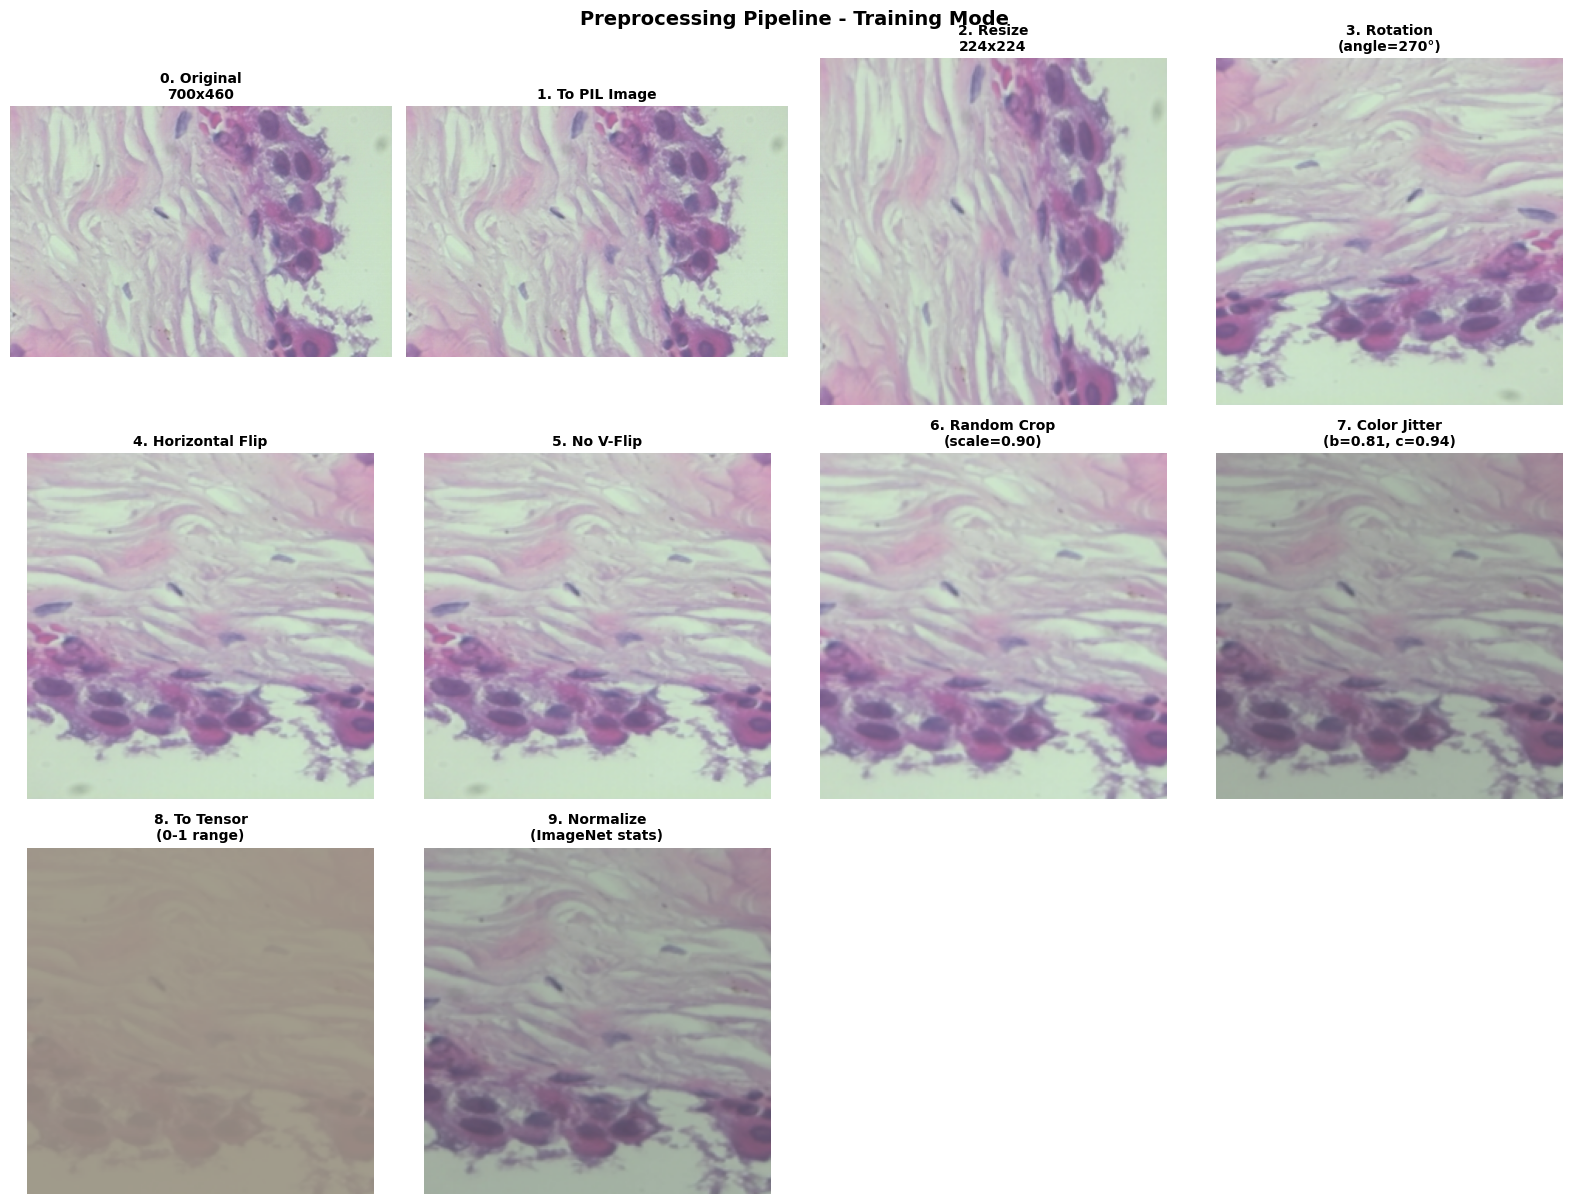


✓ Visualization complete!
Total steps: 9
Final image size: 224x224


### VALIDATION MODE PIPELINE ###
Starting visualization for validation mode...
✓ Step 0: Original
✓ Step 1: To PIL
✓ Step 2: Resize
✓ Step 3: To Tensor
✓ Step 4: Normalize

Creating visualization with 5 steps...


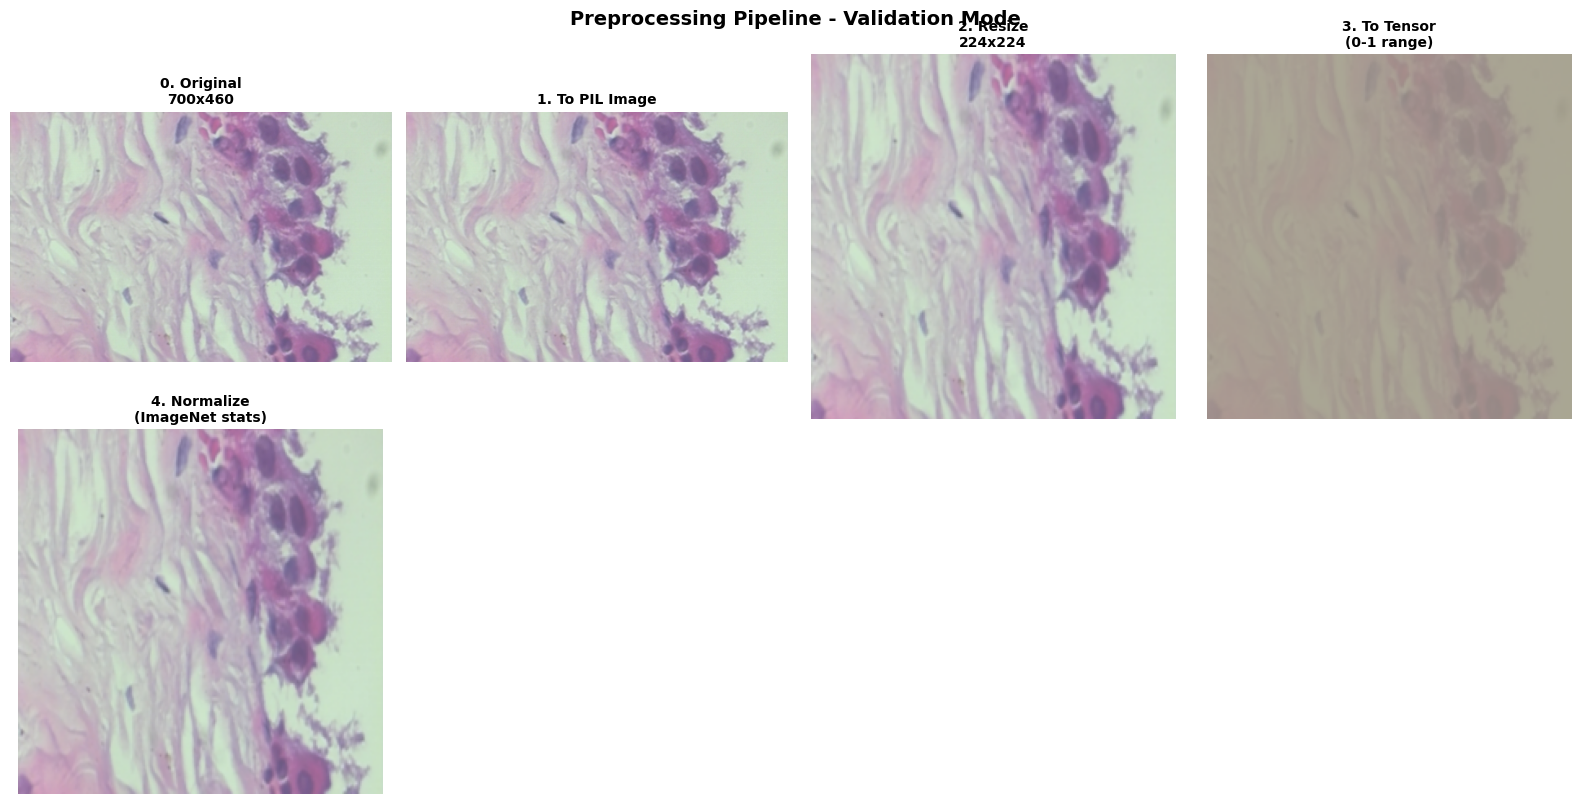


✓ Visualization complete!
Total steps: 4
Final image size: 224x224


In [57]:
# Step-by-Step Preprocessing Visualization
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torchvision.transforms.functional as F
import torchvision.transforms as transforms

# Helper: convert tensor to displayable image
def tensor_to_image(tensor):
    """Convert a normalized tensor back to displayable image"""
    if isinstance(tensor, torch.Tensor):
        # Denormalize
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        tensor = tensor * std + mean
        tensor = torch.clamp(tensor, 0, 1)
        
        # Convert to numpy
        img = tensor.permute(1, 2, 0).cpu().numpy()
        img = (img * 255).astype(np.uint8)
        return img
    return tensor

def visualize_preprocessing_steps(pipeline, sample_img_path_or_pil, is_training=True):
    """
    Visualize each step of the preprocessing pipeline
    
    Args:
        pipeline: BreakHisPreprocessingPipeline instance
        sample_img_path_or_pil: Path to image or PIL Image
        is_training: Whether to use training transforms
    """
    print(f"Starting visualization for {'training' if is_training else 'validation'} mode...")
    
    # Load image
    if isinstance(sample_img_path_or_pil, str):
        img = Image.open(sample_img_path_or_pil).convert('RGB')
    elif isinstance(sample_img_path_or_pil, Image.Image):
        img = sample_img_path_or_pil
    else:
        img = Image.fromarray(sample_img_path_or_pil)
    
    img_np = np.array(img)
    
    steps_images = []
    steps_names = []
    
    # Step 0: Original image
    steps_images.append(img_np.copy())
    steps_names.append(f'0. Original\n{img_np.shape[1]}x{img_np.shape[0]}')
    print("✓ Step 0: Original")
    
    current_img = img_np.copy()
    step_num = 1
    
    # Step 1: Image Enhancement (if enabled)
    if pipeline.config.get('image_enhancement', False):
        enhanced = pipeline.image_enhancer.enhance_image(current_img)
        steps_images.append(enhanced)
        steps_names.append(f'{step_num}. Image Enhancement')
        current_img = enhanced
        print(f"✓ Step {step_num}: Image Enhancement")
        step_num += 1
    
    # Step 2: Stain Normalization (if enabled)
    if pipeline.config.get('stain_normalization', False):
        normalized = pipeline.stain_normalizer.normalize(current_img)
        steps_images.append(normalized)
        steps_names.append(f'{step_num}. Stain Normalization')
        current_img = normalized
        print(f"✓ Step {step_num}: Stain Normalization")
        step_num += 1
    
    # Step 3: Convert to PIL and Resize
    pil_img = Image.fromarray(current_img)
    steps_images.append(np.array(pil_img))
    steps_names.append(f'{step_num}. To PIL Image')
    print(f"✓ Step {step_num}: To PIL")
    step_num += 1
    
    resized = F.resize(pil_img, (pipeline.img_size, pipeline.img_size))
    steps_images.append(np.array(resized))
    steps_names.append(f'{step_num}. Resize\n{pipeline.img_size}x{pipeline.img_size}')
    print(f"✓ Step {step_num}: Resize")
    step_num += 1
    
    current_pil = resized
    
    if is_training and pipeline.config.get('geometric_augmentation', False):
        # Step: Random Rotation (show one example)
        angle = int(np.random.choice([0, 90, 180, 270]))
        rotated = F.rotate(current_pil, angle)
        steps_images.append(np.array(rotated))
        steps_names.append(f'{step_num}. Rotation\n(angle={angle}°)')
        print(f"✓ Step {step_num}: Rotation ({angle}°)")
        step_num += 1
        current_pil = rotated
        
        # Step: Random Horizontal Flip
        if np.random.rand() < 0.5:
            flipped_h = F.hflip(current_pil)
            steps_images.append(np.array(flipped_h))
            steps_names.append(f'{step_num}. Horizontal Flip')
            current_pil = flipped_h
            print(f"✓ Step {step_num}: Horizontal Flip (applied)")
        else:
            steps_images.append(np.array(current_pil))
            steps_names.append(f'{step_num}. No H-Flip')
            print(f"✓ Step {step_num}: No Horizontal Flip")
        step_num += 1
        
        # Step: Random Vertical Flip
        if np.random.rand() < 0.5:
            flipped_v = F.vflip(current_pil)
            steps_images.append(np.array(flipped_v))
            steps_names.append(f'{step_num}. Vertical Flip')
            current_pil = flipped_v
            print(f"✓ Step {step_num}: Vertical Flip (applied)")
        else:
            steps_images.append(np.array(current_pil))
            steps_names.append(f'{step_num}. No V-Flip')
            print(f"✓ Step {step_num}: No Vertical Flip")
        step_num += 1
        
        # Step: Random Resized Crop (simplified)
        scale = np.random.uniform(0.8, 1.0)
        crop_size = int(pipeline.img_size * scale)
        
        # Random crop position
        max_offset = pipeline.img_size - crop_size
        top = np.random.randint(0, max_offset + 1) if max_offset > 0 else 0
        left = np.random.randint(0, max_offset + 1) if max_offset > 0 else 0
        
        cropped = F.resized_crop(current_pil, top, left, crop_size, crop_size, 
                                 (pipeline.img_size, pipeline.img_size))
        steps_images.append(np.array(cropped))
        steps_names.append(f'{step_num}. Random Crop\n(scale={scale:.2f})')
        print(f"✓ Step {step_num}: Random Crop (scale={scale:.2f})")
        current_pil = cropped
        step_num += 1
    
    # Step: Color Jitter (if enabled and training)
    if is_training and pipeline.config.get('color_augmentation', False):
        # Apply color jitter
        brightness_factor = np.random.uniform(0.8, 1.2)
        contrast_factor = np.random.uniform(0.8, 1.2)
        saturation_factor = np.random.uniform(0.8, 1.2)
        
        jittered = F.adjust_brightness(current_pil, brightness_factor)
        jittered = F.adjust_contrast(jittered, contrast_factor)
        jittered = F.adjust_saturation(jittered, saturation_factor)
        
        steps_images.append(np.array(jittered))
        steps_names.append(f'{step_num}. Color Jitter\n(b={brightness_factor:.2f}, c={contrast_factor:.2f})')
        print(f"✓ Step {step_num}: Color Jitter")
        current_pil = jittered
        step_num += 1
    
    # Step: Convert to Tensor
    tensor_img = F.to_tensor(current_pil)
    steps_images.append(tensor_to_image(tensor_img))
    steps_names.append(f'{step_num}. To Tensor\n(0-1 range)')
    print(f"✓ Step {step_num}: To Tensor")
    step_num += 1
    
    # Step: Normalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    normalized_tensor = (tensor_img - mean) / std
    steps_images.append(tensor_to_image(normalized_tensor))
    steps_names.append(f'{step_num}. Normalize\n(ImageNet stats)')
    print(f"✓ Step {step_num}: Normalize")
    step_num += 1
    
    # Step: Random Erasing (if enabled and training)
    if is_training and pipeline.config.get('advanced_augmentation', False):
        erased = normalized_tensor.clone()
        h, w = erased.shape[1], erased.shape[2]
        
        if np.random.rand() < 0.15:  # probability
            area = h * w
            target_area = np.random.uniform(0.02, 0.15) * area
            aspect_ratio = np.random.uniform(0.3, 3.3)
            
            h_erase = int(np.sqrt(target_area * aspect_ratio))
            w_erase = int(np.sqrt(target_area / aspect_ratio))
            
            if h_erase < h and w_erase < w:
                i = np.random.randint(0, h - h_erase)
                j = np.random.randint(0, w - w_erase)
                erased[:, i:i+h_erase, j:j+w_erase] = torch.randn(3, h_erase, w_erase)
                
            steps_images.append(tensor_to_image(erased))
            steps_names.append(f'{step_num}. Random Erasing\n(applied)')
            print(f"✓ Step {step_num}: Random Erasing (applied)")
        else:
            steps_images.append(tensor_to_image(normalized_tensor))
            steps_names.append(f'{step_num}. Random Erasing\n(not applied)')
            print(f"✓ Step {step_num}: Random Erasing (not applied)")
        step_num += 1
    
    print(f"\nCreating visualization with {len(steps_images)} steps...")
    
    # Create visualization
    n_steps = len(steps_images)
    cols = 4
    rows = (n_steps + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten() if n_steps > 1 else [axes]
    
    for idx, (img, name) in enumerate(zip(steps_images, steps_names)):
        axes[idx].imshow(img)
        axes[idx].set_title(name, fontsize=10, fontweight='bold')
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(n_steps, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f'Preprocessing Pipeline - {"Training" if is_training else "Validation"} Mode', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.show()
    
    print(f"\n✓ Visualization complete!")
    print(f"Total steps: {step_num - 1}")
    print(f"Final image size: {pipeline.img_size}x{pipeline.img_size}")

# Helper function to find sample image
def _find_sample_image():
    try:
        if 'test_dataset' in globals() and hasattr(test_dataset, 'samples') and len(test_dataset.samples) > 0:
            path = test_dataset.samples[0][0]
            print(f"Using sample from test_dataset: {path}")
            return Image.open(path).convert('RGB')
    except Exception as e:
        print('test_dataset lookup failed:', e)
    raise RuntimeError('No sample image found. Please ensure `test_dataset` exists.')

# ============= RUN VISUALIZATION =============

# Find a sample image
sample_img = _find_sample_image()
print(f"Sample image loaded: {sample_img.size}")
print("-" * 60)

# Visualize TRAINING pipeline
print("\n### TRAINING MODE PIPELINE ###")
visualize_preprocessing_steps(preprocessing_pipeline, sample_img, is_training=True)

print("\n" + "=" * 60)

# Visualize VALIDATION pipeline
print("\n### VALIDATION MODE PIPELINE ###")
visualize_preprocessing_steps(preprocessing_pipeline, sample_img, is_training=False)

In [ ]:
# Robust model loader: handles checkpoints that store 'model' or 'model_state_dict'
import torch
import sys
from importlib import import_module
import numpy as np
# Ensure repository root is on sys.path so local modules (config, model.*) can be imported
sys.path.insert(0, r'D:\thesis work\densnet-thesis')
import config

def load_checkpoint_model(checkpoint_path, device=DEVICE):
    # Use safe_globals to allowlist numpy types needed by this checkpoint (trusted local file)
    with torch.serialization.safe_globals([np._core.multiarray.scalar, np.dtype]):
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = None
    # If the checkpoint saved the whole model object (common in this repo)
    if isinstance(checkpoint, dict) and 'model' in checkpoint:
        model = checkpoint['model']
        model.to(device)
        model.eval()
        print('Loaded model object from checkpoint.')
        return model, device

    # If a state_dict is present, attempt to instantiate a model and load the weights
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        print('Checkpoint contains state_dict. Attempting to instantiate model and load weights...')
        # Try common model factories found in repository
        try:
            # Try multiclass factory first
            from model.multiclass_model import create_multiclass_model
            model = create_multiclass_model(num_classes=getattr(config, 'class_num', 2))
            model.load_state_dict(checkpoint['model_state_dict'])
            model.to(device)
            model.eval()
            print('Instantiated MultiClass model and loaded state_dict.')
            return model, device
        except Exception as e_mult:
            print('Multiclass factory failed:', e_mult)
        try:
            from model.model import class_model
            model = class_model()
            model.load_state_dict(checkpoint['model_state_dict'])
            model.to(device)
            model.eval()
            print('Instantiated binary/class_model and loaded state_dict.')
            return model, device
        except Exception as e_bin:
            print('Binary factory failed:', e_bin)

    # If checkpoint is just a model object (not dict) try that
    if not isinstance(checkpoint, dict):
        try:
            model = checkpoint
            model.to(device)
            model.eval()
            print('Checkpoint appears to be a model object (direct load).')
            return model, device
        except Exception as e_obj:
            print('Could not use checkpoint as model object:', e_obj)

    raise RuntimeError('Failed to load model from checkpoint. Please inspect the checkpoint file or update the loader cell.')

# Try to load if MODEL_PATH was discovered
model = None
if MODEL_PATH:
    model, DEVICE = load_checkpoint_model(MODEL_PATH, DEVICE)
else:
    print('No MODEL_PATH set. Set MODEL_PATH and re-run this cell to load the model.')


Loaded model object from checkpoint.
